## Initialization

In [3]:
import sys
!{sys.executable} -m pip install sympy

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 117.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 37.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [sympy]  WARNING: The script isympy is installed in '/users/rtraverfallick/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sympy]


In [30]:
import sys
sys.path.append('../src') # add the source code to the path

# These are the main files in MinScaffold/src/

import Driver
import Geometry
import Scaffold
import osmnx as ox

# These libraries are used throughout the code

import math
import numpy as np
from random import random
import networkx as nx
import pickle as pk
import matplotlib.pyplot as plt
import shapely
from shapely.geometry import Polygon
import geopandas as gpd
import pandas as pd

In [31]:
## My data: the grocery stores
# Load in different distance measures
city_path = '../Distance Matrix Construction/'
city_code = 'dal'

# All the distance matrices to consider
dist_type_list = ['geodesic','walk','drive_osm','drive_gmaps_TrafUnaware']

dist_type = dist_type_list[0]

city_fname = f'{city_code}_{dist_type}_distance_data.npz'
with np.load(city_path+city_fname) as data:
    if dist_type == 'walk':
        W = data['dal_walk_distance_seconds']
        walk_speed = data['walk_speed']
    elif dist_type == 'geodesic':
        W = data['dal_geodesic_distance_seconds']
        walk_speed = data['walk_speed']

# Symmetrize
W = W+np.transpose(W)

# Put in units of minutes
W = W/60

In [32]:
#cut off data to avoid overly dense distance matrix
if dist_type == 'walk':
    Wsave = W
    W = np.round((W<180)*W)
    W = W - np.diag(np.diag(W))
elif dist_type == 'geodesic':
    Wsave = W
    W = np.round((W<120)*W)
    W = W - np.diag(np.diag(W))
elif (dist_type[0:5] == 'drive'):
    Wsave = W
    W = np.round((W<15)*W,1)
    W = W - np.diag(np.diag(W))

In [33]:
# Geography files
#
# - ZIP codes make more sense to provide in "resource ID agnostic" location
city_path_geo = '../Data/'
pfname = 'geo_export_872fcb6c-fbde-4264-ae77-8858a604ed0e.shp'
zipfname = '../Data/Zip/dal_tx_zip.shp'

# GDF with grocery locations
groc_sites = gpd.read_file(city_path_geo+pfname)

In [37]:
#Loading street network

# Our set of grocery stores has points in Collin County 
# (It is City of Dallas, which actually crosses the county line (while also not including non-COD
#     places in Dallas Co)
# This can cause errors when attempting to find path between nodes. 

use_bbox_for_grid = True

if use_bbox_for_grid:
    # To include the southern piece of Collin Co, use bbox
    # bbox = [-97.1,32.5,-96.45,33.1]
    # bbox = [-97.8080, 32.7725, -96.7900, 32.7915]
    coords_list = [-96.808, 32.780, -96.788, 32.807]
    G = ox.graph_from_bbox(coords_list,network_type='drive', simplify=False)
   # G_df = ox.geocode.geocode_to_(bbox,network_type='walk', simplify=False)
else: 
    place = 'University Park, Texas, United States' #!! replace with desired city here
    #G = ox.graph_from_place(place,network_type='walk', buffer_dist = 5000, simplify=False)
    G = ox.graph_from_place(place,network_type='drive', simplify=False)

# coords = [
    
#     (-95.8080, 32.7725),  # Point 1
#       # Point 2
#     (-96.7900, 32.7725),
#       # Point 3
#     (-96.7900, 32.7915),
#     (-96.8080, 32.7915)
#    # Point 4
# ]
four_tuples = [
    (-96.808, 32.780),
    (-96.808, 32.807),
    (-96.788, 32.807),# Top-Left (Northwest)
    (-96.788, 32.780) # Top-Right (Northeast)
     # Bottom-Right (Southeast)
      # Bottom-Left (Southwest)
]

# Create the bounding area polygon
geo_area = Polygon(four_tuples)

geo_area
# print(f"Is this area a valid shape? {geo_area.is_valid}")

# G.draw()
datadir = '../Data/'

groc_sites = gpd.read_file(datadir+'geo_export_872fcb6c-fbde-4264-ae77-8858a604ed0e.shp') # load grocery store sites

# groc_sites.head()
groc_sites_select = groc_sites[groc_sites['city'] == 'Dallas']
groc_sites_select.head()

groc_sites_select['intersects'] = groc_sites_select.within(geo_area)
groc_sites_select_inner = groc_sites_select[groc_sites_select['intersects'] == True]

groc_sites_select_inner = groc_sites_select_inner.reset_index()

groc_sites_select_inner = groc_sites_select_inner.drop('index', axis = 1)

groc_sites_select_inner.head()

,address,city,status,store_name,geometry,intersects
0,3524 McKinney Ave,Dallas,Open,Albertsons,POINT (-96.79712 32.80557),True
1,2305 N Central Expy,Dallas,Open,Walmart Market,POINT (-96.79371 32.80061),True
2,2417 N Haskell Rd,Dallas,Open,Target,POINT (-96.79175 32.80481),True
3,4241 Capitol Ave,Dallas,Open,Kroger,POINT (-96.78975 32.80657),True
4,McKinney Ave at Routh St,Dallas,Opening,Whole Foods Market,POINT (-96.80161 32.79554),True


In [38]:
P = np.zeros((groc_sites_select_inner.shape[0],2))
#WHAT IS THIS WHY DID WE DEFINE THIS???!!!!!
NV = groc_sites_select_inner.shape[0]
for j1 in range(groc_sites_select_inner.shape[0]):
    P[j1,:]=[groc_sites_select_inner.loc[j1,'geometry'].x, groc_sites_select_inner.loc[j1,'geometry'].y] 

## Network Visualization

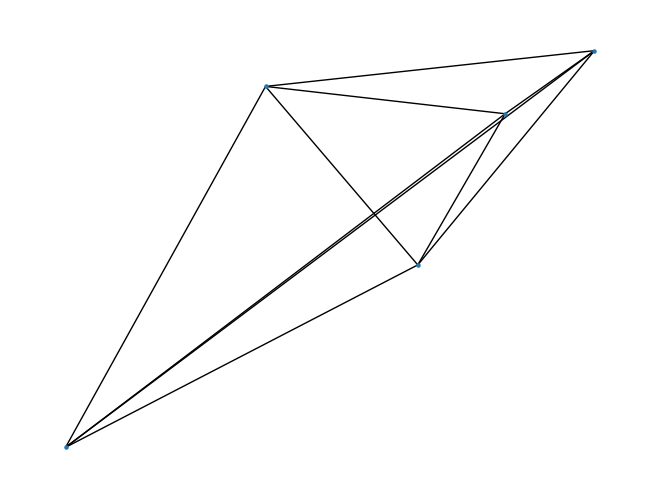

In [39]:
G = nx.Graph(W) # create a nx object

# Plot the input weighted graph.
nx.draw(G, pos=P, node_size=5)

## Scaffold

### Creating Minimal Scaffold

In [40]:
epsList = Geometry.genFullEpsList(W) # create list of filtration parameters

In [41]:
print(epsList)

[0.001, 6.001, 12.001, 15.001, 16.001, 18.001, 22.001, 28.001, 32.001, 39.001]


In [42]:
# compute minimal generators for each filtration value
F = Driver.getFiltrBasis(W, epsList, Draws=False, parallel=False, monitor=None)

In [43]:
numCyc = [x[1].card() for x in F.Elements]

epsLev = [x[0] for x in F.Elements]

In [44]:
#compute the adjacency matrix of the minimal scaffold.
S = Scaffold.frequency_Scaffold(F , len(P))

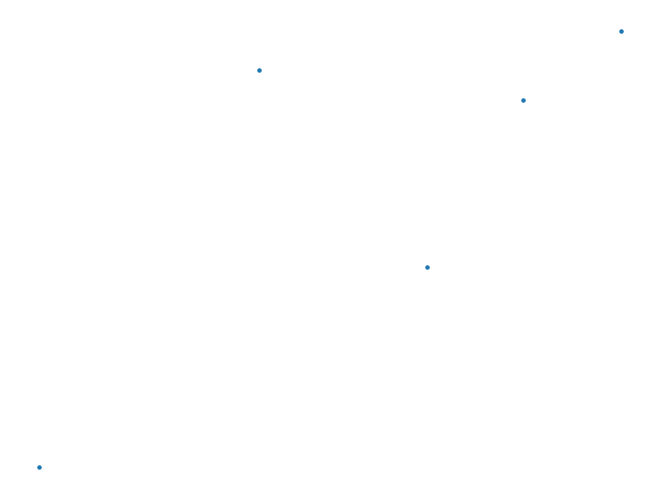

In [46]:
Scaf = nx.from_numpy_array(S, parallel_edges=False)
nx.draw(Scaf,pos=P, node_size=5)

### Exploring Bases

In [47]:
# Create a list of homology bases
Bas = []
for (step,B) in F.Elements: 
    Bas.append(B) # store the basis, discarding the filtration step value

In [49]:
# Load in zip file of grocery sites underneath 
zipfname = '../Data/dal_tx_zip.shp'
city_df = gpd.read_file(zipfname)

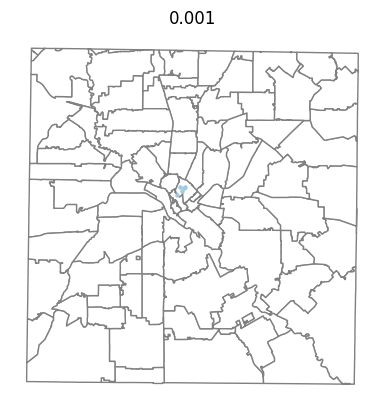

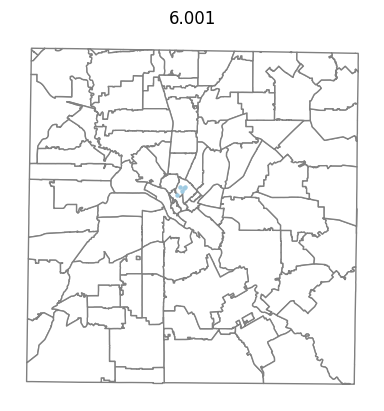

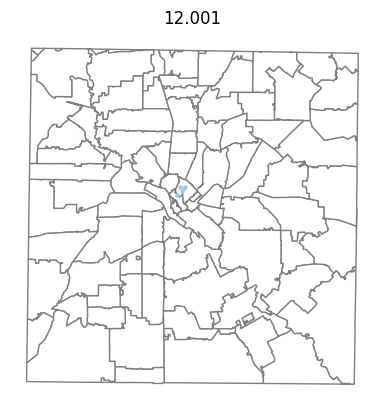

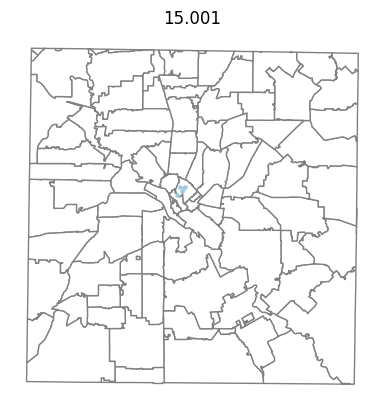

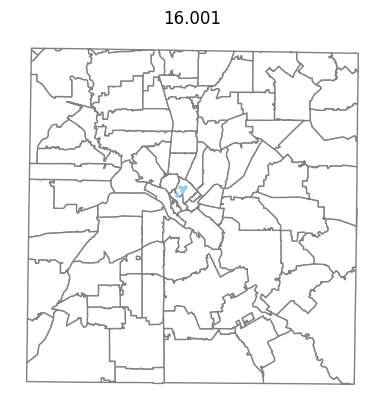

In [51]:
#Print selected minimal generators

np.set_printoptions(threshold=np.inf)
# indices = 90+2*np.array(range(10))
indices = np.array(range(5))

colors = [1,2,3]
options = {
    "node_color": "#A0CBE2",
    "edge_color": "#1133EE",
    "width": 4,
    "edge_cmap": plt.cm.Blues,
    "with_labels": False,
}
edge_color_list = ["#1133EE","#6699EE","#AABBEE"]

# Depending on the length of the filtration, choose a suitable step that contains nontrivial homology
for j1 in range(len(indices)):
    fig , ax1= plt.subplots()
    city_df.plot(ax=ax1, color='white', edgecolor='grey')
    #options["edge_color"]=edge_color_list[np.mod(j1,3)]
    
    whichB = indices[j1]
    B = Bas[whichB]
    #print(P)
    #print(M)
    #print(whichB)
    M = Scaffold.matrix_Basis( B , len(P) , np.array(F.get_edgeList()) )
    
    
    # Plot the basis at the given step, using the layout object as done above
    nx.draw( nx.Graph(M) , pos = P , node_size=5, **options, ax=ax1)
    S = [nx.Graph(M).subgraph(c).copy() for c in nx.connected_components(nx.Graph(M))]
    plt.title(epsLev[whichB])
    #plt.savefig(f'../Cycles_Dallas/dal_tx_MinCycles_{dist_type}_{str(whichB)}.jpeg', \
                #bbox_inches="tight", dpi = 300)
    plt.show()
    

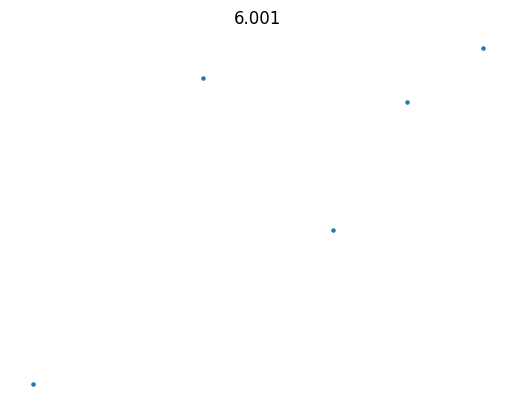

In [52]:
# Print selected minimal generators
i = 0
for (e,B) in F.Elements:
    i += 1
    if np.mod(i,10)==1:
        fig , ax1= plt.subplots()
        M = Scaffold.matrix_Basis( B , len(P) , np.array(F.get_edgeList()) )
        nx.draw( nx.Graph(M) , pos = P , node_size=5, ax=ax1 )
        plt.title(epsLev[i])
        plt.show()

## Visualizing Holes using Shapely

In [53]:
# In polygons_list, store list of vertices that make up each hole

np.set_printoptions(threshold=np.inf)
indices = range(len(epsList))

polygons_list = [];
for j1 in range(len(indices)):
    whichB = indices[j1]
    B = Bas[whichB]
    M = Scaffold.matrix_Basis( B , len(P) , np.array(F.get_edgeList()) )
    S = [nx.Graph(M).subgraph(c).copy() for c in nx.connected_components(nx.Graph(M))]
    polygons = []
    for component in S:
        if len(component.nodes) > 1:
            path = []
            cycle = nx.find_cycle(component)
            for edge in cycle: 
                path.append(edge[0])
            polygons.append(path)
    polygons_list.append(polygons)

In [54]:
polygons_list

[[], [], [], [], [], [], [], [], [], []]

In [57]:

# Load Census block geography (will be needed for population)
#blockfname = '../Dallas/Block/dal_tx_block.shp'

# Stored somewhere else, because of size
blockdir = '../../tda-resources-dallas/Dallas/'
blockfile = 'Block/dal_tx_block.shp'

# Geography files
# - why provide full path: we have multiple resources. 
# - ZIP codes make more sense to provide in "resource ID agnostic" location
pfname = '../Data/geo_export_872fcb6c-fbde-4264-ae77-8858a604ed0e.shp'
zipfname = '../Data/dal_tx_zip.shp'

In [56]:
block_df = gpd.read_file(blockdir+blockfile)
groc_df  = gpd.read_file(pfname)
zip_df = gpd.read_file(zipfname)

DataSourceError: ../../tda-resources-dallas/Dallas/Block/dal_tx_block.shp: No such file or directory

In [21]:
sqm_to_sqmi_convert = 2589988

# Assuming "ALAND' and "POP20" are accurate:
block_df['PopDens']=block_df['POP20']/block_df['ALAND20']*sqm_to_sqmi_convert

In [22]:
# Coordinate systems
meters_per_mile = 1609.34
crs = {
    'census': 'EPSG:4269'  , # degrees - used by Census
    'projected': 'EPSG:3083',         # projected; needed for maup
    'area'  : 'ESRI:102003', # meters
    'length': 'ESRI:102005', # meters
}
'''
EPSG:3083
Coordinate System: 	
Cartesian 2D CS. Axes: easting, northing (X,Y). 
Orientations: east, north. UoM: m.Open
Base CRS: 	
NAD83Open
Conversion: 	
Texas Centric Albers Equal Area
'''

'\nEPSG:3083\nCoordinate System: \t\nCartesian 2D CS. Axes: easting, northing (X,Y). \nOrientations: east, north. UoM: m.Open\nBase CRS: \t\nNAD83Open\nConversion: \t\nTexas Centric Albers Equal Area\n'

In [23]:
# Project all into CRS
block_df.geometry = block_df.geometry.to_crs(crs['projected'])
groc_df.geometry = groc_df.geometry.to_crs(crs['projected'])

In [24]:
geo_walk_conversion_rate = 1.14 # adjustment factor to compensate for walking distance being longer than geodesic distance

83.001
1767.9213


/var/folders/cy/h13gdsk90z9b0q3yb1tc6v9c0000gn/T/ipykernel_395/1472206698.py:58: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  county_with_holes_union = county_with_holes_union.geometry.union(min_cycle_df)
/var/folders/cy/h13gdsk90z9b0q3yb1tc6v9c0000gn/T/ipykernel_395/1472206698.py:58: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can p

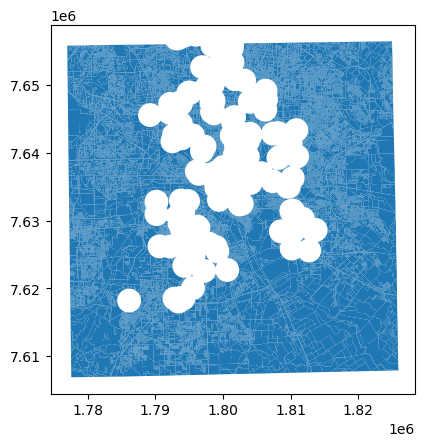

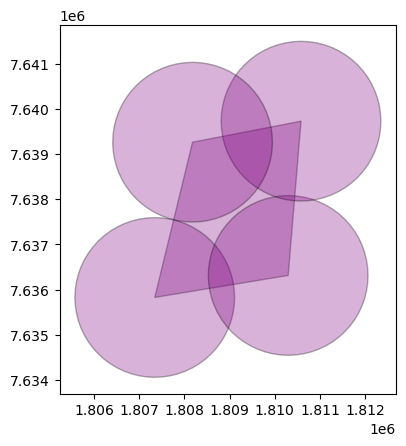

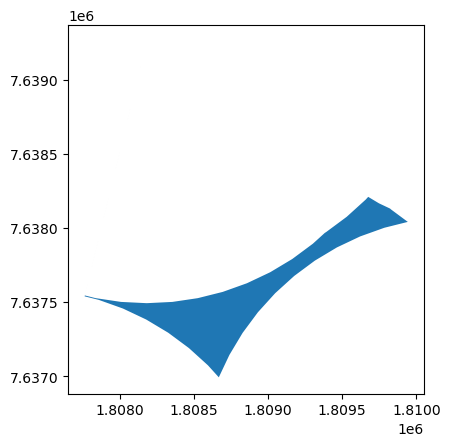

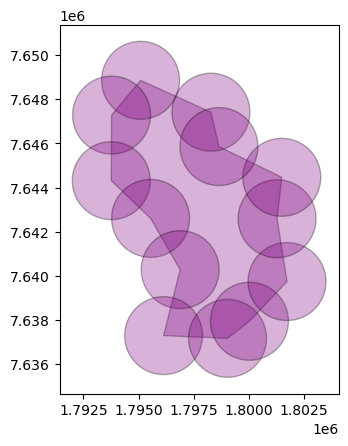

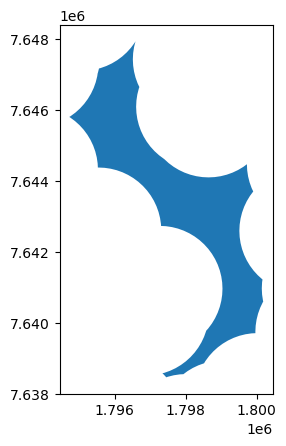

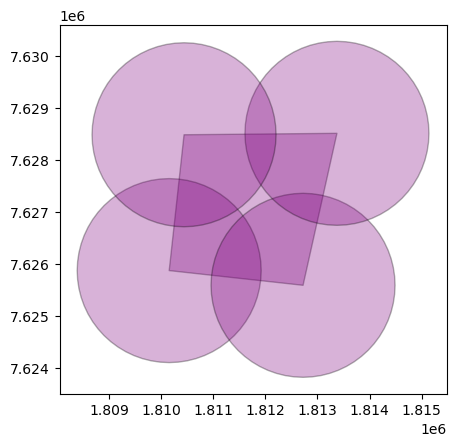

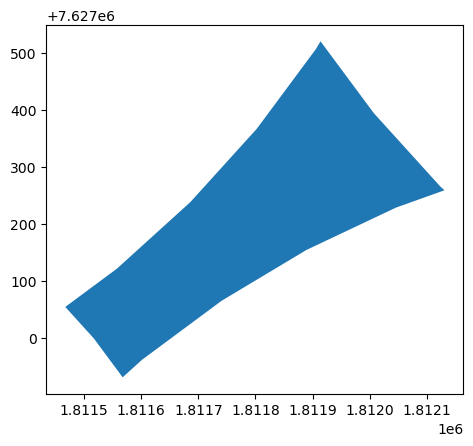

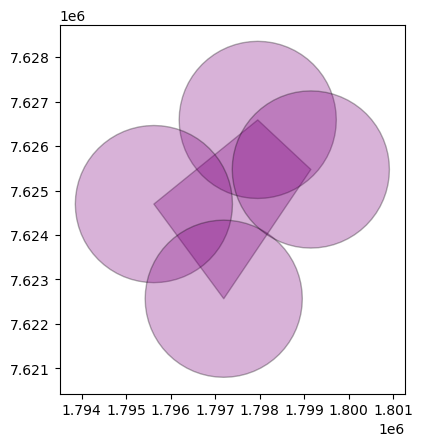

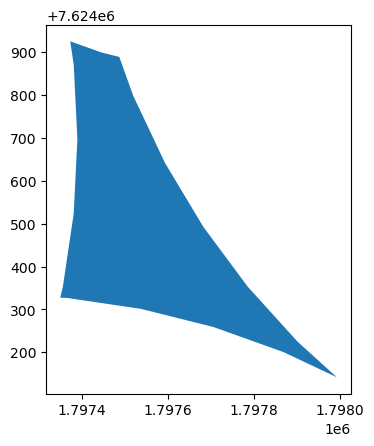

In [35]:
# Visualize holes for a given index
indices = [80]
for i in indices:
    print(epsList[i])
    if dist_type == 'walk':
        radius_serv_area = epsList[i] * 60 * walk_speed / (4 * geo_walk_conversion_rate)
    elif dist_type == 'geodesic':
        radius_serv_area = epsList[i] * 60 * walk_speed / 4
    print(radius_serv_area)

    # Create service areas of all grocery stores, with the given radius
    service_areas = groc_df.geometry.buffer(radius_serv_area)
    service_areas_all = service_areas.union_all()
    service_area_holes = block_df.geometry.intersection(service_areas_all)

    # The rest of the area NOT included in the service areas
    county_with_holes = block_df['geometry'].difference(service_area_holes)
    county_with_holes.plot()
    county_with_holes_union = county_with_holes

    # Keep each of the "swiss cheese" shapes
    min_cycle_hole_df = pd.DataFrame(data=[], columns=['poly','geometry'])
    
    for poly in polygons_list[i]:
        # "poly" contains the Dataframe indices
        groc_df_lim = groc_df.loc[poly]

        # Create a polygon from the vertices
        min_cycle_area = Polygon(groc_df_lim['geometry'])
        list_of_areas = [min_cycle_area]
        # Also get services areas from each vertex on cycle.
        # Put all in a single list, for visualization
        for l in poly:
            service_area_pt = groc_df.loc[l].geometry.buffer(radius_serv_area)
            list_of_areas.append(service_area_pt)

        if False:
            # Union of all service areas from vertices
            service_areas_lim = groc_df_lim.geometry.buffer(radius_serv_area)
            service_areas_all_lim = service_areas_lim.union_all()

            ## ???
            service_area_holes_lim = block_df.geometry.intersection(service_areas_all_lim)
            #min_cycle_area = Polygon(groc_df_lim['geometry'])
        
        min_cycle_df = gpd.GeoDataFrame(data = [[poly]], \
                                geometry=gpd.GeoSeries(min_cycle_area),\
                               crs=crs['projected'])
        min_cycle_df=min_cycle_df.rename(columns={0:'Cycle vertices'})
        #shapes = gpd.GeoSeries([min_cycle_area, service_areas_all_lim])

        # List of the shapes to illustrate how "service areas" overlap with the cycle
        shapes = gpd.GeoSeries(list_of_areas)
        shapes.plot(color='purple',alpha = 0.3,edgecolor='k')
        
        #min_cycle_df.plot()
        # Why do we do this?
        county_with_holes_union = county_with_holes_union.geometry.union(min_cycle_df)

        # This is intersection with the cycle area AND the service areas
        # note it is ALL service areas, not just ones on the boundary. So its shape may
        # be slightly different than the illustration with the polygon + circles
        #
        # (why named "cycle_holes"? because we will delete them from the cycle)
        cycle_holes = min_cycle_df.geometry.intersection(service_areas_all)

        # Now subtract (via set difference, those intersections from the area of the cycle)
        cycle_with_holes = min_cycle_df.difference(cycle_holes)
        cycle_with_holes.plot()

        newrow = pd.DataFrame(data={'poly':[poly], 'geometry': [cycle_with_holes[0]]})
        min_cycle_hole_df = pd.concat([min_cycle_hole_df,newrow],ignore_index=True)

In [36]:
min_cycle_hole_gdf = gpd.GeoDataFrame(min_cycle_hole_df,geometry=min_cycle_hole_df['geometry'])

<Axes: >

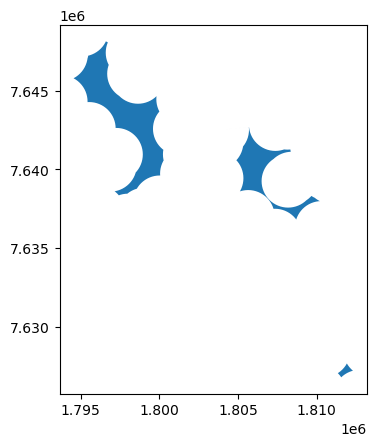

In [32]:
min_cycle_hole_gdf.plot()

In [37]:
# POPULATION INSIDE HOLE
#
# This is only for one filtration value.
# I kept intermediate values (like intersection area, etc.) in case we want to look more closely
#    at the results
# Have not attempted to optimize in speed or efficiency
# 

interpop = pd.Series(index=min_cycle_hole_gdf.index)

for cycleind,cyclerow in min_cycle_hole_gdf.iterrows():

    # For a single hole, find all non-empty intersections with Census blocks
    mytemp=cyclerow['geometry'].intersection(block_df['geometry'])
    actualInt = mytemp[~mytemp.is_empty]

    # Iterate through Census blocks. For each track area, intersection area, populations
    actualInt=pd.DataFrame(actualInt)
    blkarea = pd.Series(index=actualInt.index)
    intarea = pd.Series(index=actualInt.index)
    blkpop = pd.Series(index=actualInt.index)

    for index, value in actualInt.iterrows():
        blkarea[index]=block_df.loc[index].geometry.area
        intarea[index]=actualInt.loc[index].geometry.area
        blkpop[index]=block_df.loc[index]['POP20']

    # Put back into "actualInt" dataframe
    actualInt['Block area']=blkarea
    actualInt['Intersection area']=intarea
    actualInt['Block pop']=blkpop

    actualInt['Intersection pop']= blkpop*intarea/blkarea

    interpop[cycleind]=actualInt['Intersection pop'].sum()

min_cycle_hole_gdf['Population']= interpop


In [40]:
# Total # of people inconvenienced for this specific filtration value
min_cycle_hole_gdf['Population'].sum()

np.float64(16987.408219109093)

In [34]:
min_cycle_hole_gdf.head()

,poly,geometry,Population
0,"[111, 131, 86, 46, 80, 112, 6, 75, 106, 133, 1...","POLYGON ((1799714.569 7644557.324, 1799824.96 ...",19064.680388
1,"[32, 120, 26, 62, 1, 10, 3, 136]","POLYGON ((1805697.194 7642693.231, 1805720.881...",3285.608150
2,"[123, 7, 31, 84]","POLYGON ((1811655.061 7626895.718, 1811554.238...",577.831840
